# L2a Advanced: Pricing Defaultable Securities with Bernoulli Payment Indicators

The L2a lecture treated Treasury payments as promised cash flows. This optional example asks what changes when a payment may not arrive. We represent payment with a Bernoulli indicator, price the resulting random cash flow by its expected discounted value under a simple risk-neutral assumption, add recovery following default, and then extend the idea to coupon securities. We finish by checking the analytical coupon-security price with a Monte Carlo simulation.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Price a defaultable zero-coupon security.__ You will represent whether a promised payment arrives with a Bernoulli indicator, calculate the expected discounted payment, and explain how default probability and recovery affect the price and promised yield.
> * __Connect coupon payments through one default event.__ You will construct survival indicators that stop all later payments after default instead of treating coupon receipts as independent events.
> * __Verify an analytical price by simulation.__ You will simulate defaultable coupon cash flows and compare their Monte Carlo average with the expected-value formula.

We will make the promised cash flows random.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
# Load the advanced module's course environment and package imports.
include(joinpath(@__DIR__, "Include.jl"));

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activated the course project and loaded [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for Bernoulli random variables, the [`Random`](https://docs.julialang.org/en/v1/stdlib/Random/) and [`Statistics`](https://docs.julialang.org/en/v1/stdlib/Statistics/) standard libraries for simulation, [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for result tables, and [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures. This notebook defines its pricing calculations directly in code cells.

Next, we set the plotting defaults:

In [2]:
# Set one visual style for every plot in this notebook.
default(
    fontfamily = "Helvetica",           # match the lecture graphics
    framestyle = :box,                 # draw all four plot borders
    background_color = :gray97,        # light gray plotting area
    background_color_outside = :white, # white margin around the axes
    legend_background_color = nothing, # transparent legend background
    linewidth = 2,                     # default line width
);

___

## 1. A zero-coupon security with a Bernoulli payment

Let $I_T$ indicate whether the face-value payment $V_P$ is received at maturity:
$$
I_T\sim\operatorname{Bernoulli}(S_T),\qquad
I_T=\begin{cases}1,&\text{the payment is received},\\0,&\text{the issuer defaults}.\end{cases}
$$
The parameter $S_T=\mathbb P(I_T=1)$ is the probability that the issuer survives through maturity. With no recovery following default, the random maturity payment is $\widetilde c_T=V_PI_T$. If $d_T=e^{-g_0T}$ is a default-free discount factor, setting expected discounted NPV equal to zero gives
$$
0=-V_B+d_T\,\mathbb E[\widetilde c_T]\qquad\Longrightarrow\qquad\boxed{V_B=d_TV_PS_T}.
$$

> __Simplifying pricing assumption.__ We discount the expected payment at the default-free rate. This is the usual risk-neutral calculation. If $S_T$ is instead an ordinary forecast of real-world survival, the same formula additionally assumes that investors require no extra compensation for bearing default risk. Market prices generally reflect risk-adjusted survival probabilities as well as other market conditions.

Let's calculate an example with a five-year maturity and a 90% survival probability.

In [3]:
# Define the zero-coupon promise, valuation horizon, and default assumptions.
V_P = 100.0;      # promised face value at maturity, in USD
T = 5.0;          # years from valuation to maturity
g₀ = 0.04;        # default-free continuously compounded rate, year⁻¹
S_T = 0.90;       # survival probability: Pr(face value is paid at T)
d_T = exp(-g₀*T); # default-free discount factor from T back to time 0

# Represent repayment with a Bernoulli indicator: I_T = 1 if the bond survives.
I_T = Bernoulli(S_T); # E[I_T] = S_T

# Compute the analytical prices and the yield promised by the lower market price.
default_free_price = d_T*V_P;                    # certain discounted face value
defaultable_price = d_T*V_P*mean(I_T);          # discounted expected repayment
promised_log_yield = log(V_P/defaultable_price)/T; # yield implied by promised face value
promised_yield_spread = promised_log_yield - g₀;  # excess over the default-free rate

# Assemble the analytical results; multiply decimal rates by 100 for display.
zero_coupon_results = DataFrame(
    measure = ["Default-free price", "Defaultable price", "Promised log yield", "Promised-yield spread"],
    value = [default_free_price, defaultable_price, 100*promised_log_yield, 100*promised_yield_spread],
    units = ["USD", "USD", "percent/year", "percentage points/year"],
)
zero_coupon_results # display the completed result table

Row,measure,value,units
,String,Float64,String
1,Default-free price,81.8731,USD
2,Defaultable price,73.6858,USD
3,Promised log yield,6.10721,percent/year
4,Promised-yield spread,2.10721,percentage points/year


The price formula uses $\mathbb E[I_T]=S_T$. We can verify that expectation by drawing many Bernoulli indicators. The Monte Carlo price is the discounted average of the simulated maturity payments. Its standard error measures the remaining sampling noise.

In [4]:
# Configure a reproducible Monte Carlo estimate of the expected repayment.
M_zero = 100_000;                 # number of simulated maturity outcomes
rng_zero = MersenneTwister(5660); # fixed seed makes the example reproducible
payment_indicators = rand(rng_zero, I_T, M_zero); # 1 = paid, 0 = default

# Estimate the discounted price and the standard error of the sample mean.
zero_mc_price = d_T*V_P*mean(payment_indicators);
zero_mc_standard_error = d_T*V_P*std(payment_indicators)/sqrt(M_zero);

# The simulated price should lie within four estimated standard errors.
@assert abs(zero_mc_price - defaultable_price) ≤ 4*zero_mc_standard_error

# Compare the analytical expectation with the simulation estimate.
zero_mc_comparison = DataFrame(
    method = ["Analytical expectation", "Monte Carlo"],
    price_USD = [defaultable_price, zero_mc_price],
    standard_error_USD = Union{Missing,Float64}[missing, zero_mc_standard_error],
)
zero_mc_comparison # display the comparison table

Row,method,price_USD,standard_error_USD
,String,Float64,Float64?
1,Analytical expectation,73.6858,missing
2,Monte Carlo,73.5957,0.0780503


### How does default probability affect price and promised yield?

Let $q_T=1-S_T$ be the probability of default before maturity. With zero recovery,
$$
V_B=d_TV_P(1-q_T),\qquad
g_B=\frac{1}{T}\log\left(\frac{V_P}{V_B}\right)=g_0-\frac{1}{T}\log(1-q_T).
$$
The quantity $g_B$ is the promised log yield calculated from price and the full face-value promise. A larger default probability lowers price and raises this promised yield, but the larger yield is not a guaranteed realized return because the full payment may not arrive.

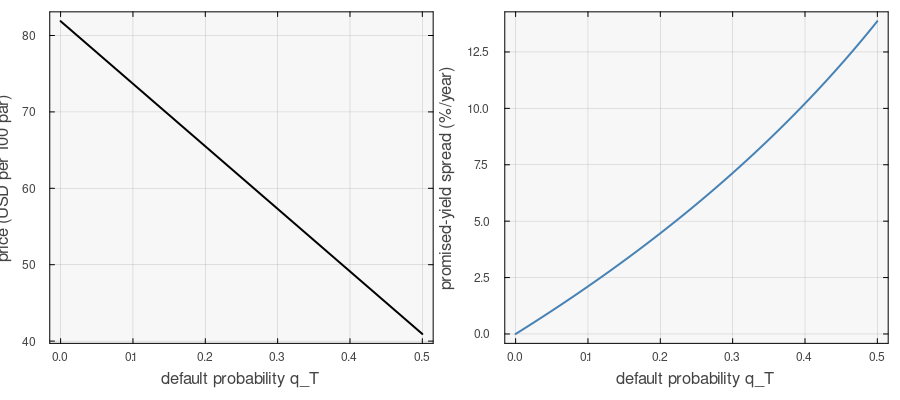

In [5]:
# Evaluate prices and promised-yield spreads over terminal default probabilities.
q_values = range(0.0, 0.50, length = 101); # q_T = Pr(default before payment)
survival_values = 1 .- q_values;           # S_T = 1 - q_T
price_values = d_T*V_P .* survival_values; # zero-recovery expected price
spread_values = -log.(survival_values)./T; # spread = -log(S_T)/T

# Plot the price decline and yield-spread increase on separate axes.
p_price = plot(q_values, price_values; color = :black, label = nothing,
    xlabel = "default probability q_T", ylabel = "price (USD per 100 par)")
p_spread = plot(q_values, 100 .* spread_values; color = :steelblue, label = nothing,
    xlabel = "default probability q_T", ylabel = "promised-yield spread (%/year)")
plot(p_price, p_spread; layout = (1, 2), size = (900, 400),
    bottom_margin = 6 * Plots.mm)

___

## 2. Recovery following default

Default does not always reduce the payment to zero. Let $R\in[0,1]$ be the fraction of face value recovered following default. The maturity payment becomes
$$
\widetilde c_T=V_P\left[I_T+R(1-I_T)\right],
$$
and its price is
$$
\boxed{V_B=d_TV_P\left[S_T+R(1-S_T)\right]}.
$$
A larger recovery cushions the price against default. At $R=1$, the promised face value is effectively received in either state, so the price returns to the default-free value.

In [6]:
# Hold terminal default probability fixed and vary the fraction recovered in default.
q_T = 0.10; # terminal default probability
recovery_values = [0.00, 0.25, 0.50, 0.75, 1.00]; # fraction of par recovered

# Expected payoff fraction is (1 - q_T) + R*q_T for recovery fraction R.
recovery_prices = d_T*V_P .* ((1 - q_T) .+ recovery_values .* q_T);
recovery_yields = log.(V_P ./ recovery_prices)./T; # promised log yields

# Report the price, promised yield, and spread for each recovery assumption.
recovery_table = DataFrame(
    recovery_fraction = recovery_values,
    price_USD = recovery_prices,
    promised_log_yield_percent = 100 .* recovery_yields,
    promised_yield_spread_percent = 100 .* (recovery_yields .- g₀),
)
recovery_table # display the recovery comparison

Row,recovery_fraction,price_USD,promised_log_yield_percent,promised_yield_spread_percent
,Float64,Float64,Float64,Float64
1,0.0,73.6858,6.10721,2.10721
2,0.25,75.7326,5.55923,1.55923
3,0.5,77.7794,5.02587,1.02587
4,0.75,79.8262,4.50636,0.506356
5,1.0,81.8731,4.0,0.0


Next, we vary default probability and recovery together. Default matters less to price when a larger fraction of face value is recovered.

In [7]:
let
    # Use one default-probability grid for every recovery curve.
    q_grid = range(0.0, 0.50, length = 101);
    p = plot(; xlabel = "default probability q_T",
        ylabel = "price (USD per 100 par)");

    # Reprice the zero-coupon bond for four fixed recovery fractions.
    for (R, color) ∈ zip((0.00, 0.25, 0.50, 0.75), (:black, :gray45, :steelblue, :darkorange))
        prices = d_T*V_P .* ((1 .- q_grid) .+ R .* q_grid); # discounted expected payoff
        plot!(p, q_grid, prices; color = color, label = "recovery R = $(R)");
    end

    p # display the completed multi-curve plot
end;

___

## 3. Price a coupon security with one default history

We could assign a Bernoulli indicator to every coupon, but treating those indicators as independent would allow an issuer to miss one coupon and then resume later payments as if nothing happened. A simple default model instead introduces one default time $\tau$ and defines
$$
I_j=\mathbf 1_{\{\tau>t_j\}},\qquad S_j=\mathbb P(I_j=1).
$$
The indicators satisfy $I_{j+1}\leq I_j$: after default, every later survival indicator remains zero. If $C$ is the coupon, $V_P$ is face value, and there is no recovery, the price is
$$
V_B=C\sum_{j=1}^{N}d_jS_j+V_Pd_NS_N.
$$
With recovery fraction $R$ paid at the end of the period in which default occurs, the recovery term is
$$
RV_P\sum_{j=1}^{N}d_j(S_{j-1}-S_j),\qquad S_0=1.
$$
The difference $S_{j-1}-S_j$ is the probability that the first default occurs during period $j$. We will use a constant conditional default probability $q_{\Delta}$ per coupon period, so $S_j=(1-q_{\Delta})^j$.

In [8]:
# Define the coupon security and the per-period default model.
V_P_coupon = 100.0; # face value paid at maturity if the bond survives, in USD
T_coupon = 5.0;     # years to maturity
n = 2;              # coupon periods per year
N = Int(n*T_coupon); # total number of coupon periods
c = 0.05;           # annual coupon rate as a decimal
C = (c/n)*V_P_coupon; # coupon paid each period, in USD
q_period = 0.02;    # conditional default probability in each surviving period
R_coupon = 0.40;    # recovery fraction of par paid at default

# Build the time, discount, survival, and default-probability vectors.
periods = collect(1:N);       # financial indexes 1,...,N
times = periods ./ n;         # payment times measured in years
discounts = exp.(-g₀ .* times); # default-free time-0 discount factors
survival = (1 - q_period) .^ periods; # probability of surviving through each period
survival_previous = vcat(1.0, survival[1:end-1]); # survival at the start of each period
default_in_period = survival_previous .- survival; # unconditional default probability

# Discount the expected coupon and recovery payments in each period.
expected_coupon_PV = discounts .* C .* survival; # coupon is paid only after survival
expected_recovery_PV = discounts .* R_coupon .* V_P_coupon .* default_in_period;

# Assemble the period-by-period analytical schedule.
coupon_schedule = DataFrame(
    period = periods,
    time_years = times,
    survival_probability = survival,
    default_probability_in_period = default_in_period,
    expected_coupon_PV_USD = expected_coupon_PV,
    expected_recovery_PV_USD = expected_recovery_PV,
)
coupon_schedule # display the expected-payment schedule

Row,period,time_years,survival_probability,default_probability_in_period,expected_coupon_PV_USD,expected_recovery_PV_USD
,Int64,Float64,Float64,Float64,Float64,Float64
1,1,0.5,0.98,0.02,2.40149,0.784159
2,2,1.0,0.9604,0.0196,2.30686,0.753259
3,3,1.5,0.941192,0.019208,2.21595,0.723577
4,4,2.0,0.922368,0.0188238,2.12863,0.695064
5,5,2.5,0.903921,0.0184474,2.04475,0.667675
6,6,3.0,0.885842,0.0180784,1.96418,0.641365
7,7,3.5,0.868126,0.0177168,1.88678,0.616091
8,8,4.0,0.850763,0.0173625,1.81243,0.591814
9,9,4.5,0.833748,0.0170153,1.74101,0.568494


In [9]:
# Sum the expected present values of the three defaultable payment legs.
coupon_leg = sum(expected_coupon_PV); # coupons received while the bond survives
principal_leg = discounts[end]*V_P_coupon*survival[end]; # par paid after survival to N
recovery_leg = sum(expected_recovery_PV); # recovery paid in the default period
defaultable_coupon_price = coupon_leg + principal_leg + recovery_leg;

# Price the same promised cash flows with no possibility of default.
default_free_coupon_price = sum(discounts .* C) + discounts[end]*V_P_coupon;

# Check that survival declines and default risk lowers the security's price.
@assert all(diff(survival) .≤ 0.0)
@assert defaultable_coupon_price < default_free_coupon_price

# Report the component present values and both total prices.
coupon_price_components = DataFrame(
    component = ["Expected coupon leg", "Expected principal leg", "Expected recovery leg", "Defaultable price", "Default-free price"],
    present_value_USD = [coupon_leg, principal_leg, recovery_leg, defaultable_coupon_price, default_free_coupon_price],
)
coupon_price_components # display the price decomposition

Row,component,present_value_USD
,String,Float64
1,Expected coupon leg,20.1745
2,Expected principal leg,66.8963
3,Expected recovery leg,6.58759
4,Defaultable price,93.6583
5,Default-free price,104.306


The coupon and principal legs shrink because they are paid only when the issuer survives to their payment dates. The recovery leg adds back part of the loss when default occurs. This decomposition separates promised payments from expected payments without pretending that coupon defaults are independent.

### Verify the coupon-security price by Monte Carlo

The analytical calculation adds the expected present values of all coupon, principal, and recovery payments. The simulation generates one default history per path. During each coupon period, a Bernoulli draw determines whether default occurs. If it does, the path receives recovery and stops; otherwise, it receives the coupon and moves to the next period. A surviving final path also receives face value.

In [10]:
# Estimate a defaultable coupon security's price by simulating independent
# Bernoulli default events in successive coupon periods.
function simulate_coupon_security(V_P::Real, c::Real, n::Int, N::Int, g₀::Real, q_period::Real, R::Real;
        number_of_paths::Int = 200_000, seed::Int = 5660)

    # Initialize the random stream, per-period default event, and result vector.
    rng = MersenneTwister(seed);     # local generator keeps the simulation reproducible
    default_event = Bernoulli(q_period); # 1 indicates default in the current period
    C = (c/n)*V_P;                   # coupon paid per surviving period, in USD
    present_values = zeros(Float64, number_of_paths); # one path value per simulation

    # Simulate the discounted payments received along each path.
    for path ∈ 1:number_of_paths
        value = 0.0; # accumulated time-0 value for this path

        # Move forward through coupon periods until maturity or default.
        for j ∈ 1:N
            discount_factor = exp(-g₀*(j/n)); # period-j payment discounted to time 0

            if rand(rng, default_event) == 1
                # Default ends the contract after the recovery payment; no coupon
                # is paid in the default period under this model.
                value += discount_factor*R*V_P;
                break
            else
                value += discount_factor*C; # surviving bond pays its coupon
                if j == N
                    value += discount_factor*V_P; # maturity survival also pays par
                end
            end
        end

        present_values[path] = value; # store the completed path value
    end

    # Return the sample mean and its estimated standard error.
    return (
        price = mean(present_values),
        standard_error = std(present_values)/sqrt(number_of_paths),
        number_of_paths = number_of_paths,
    )
end

simulate_coupon_security (generic function with 1 method)

In [11]:
# Simulate the same coupon security used in the analytical calculation.
coupon_mc = simulate_coupon_security(
    V_P_coupon, c, n, N, g₀, q_period, R_coupon
);

# Express the analytical-versus-simulated price difference in standard errors.
difference_in_standard_errors =
    (coupon_mc.price - defaultable_coupon_price) / coupon_mc.standard_error;

# The Monte Carlo estimate should lie within four estimated standard errors.
@assert abs(difference_in_standard_errors) ≤ 4.0

# Display the analytical price beside the simulation estimate and uncertainty.
coupon_mc_comparison = DataFrame(
    method = ["Analytical expectation", "Monte Carlo"],
    price_USD = [defaultable_coupon_price, coupon_mc.price],
    standard_error_USD = Union{Missing,Float64}[missing, coupon_mc.standard_error],
)
coupon_mc_comparison # display the final validation table

Row,method,price_USD,standard_error_USD
,String,Float64,Float64?
1,Analytical expectation,93.6583,missing
2,Monte Carlo,93.6009,0.0505909


### Discussion Questions

1. Why does treating coupon-payment indicators as independent events produce unrealistic default histories?
2. Why does a larger promised yield not guarantee a larger realized return for a defaultable security?
3. How do default probability and recovery affect the price through different parts of the expected cash flow?
4. Why might a survival probability inferred from a market price differ from the default frequency estimated from historical data?
5. Which assumptions would need to change if default could occur at any time rather than only once per coupon period?
___

## Summary

This example replaced fixed promised payments with random payments and used a simple expected-value pricing rule to connect default risk with price.

> __Key Takeaways:__
>
> * __A Bernoulli indicator turns a promised payment into a random cash flow.__ Its survival probability scales the expected payment in the pricing equation, so greater default risk lowers the price and raises the promised yield while greater recovery cushions the loss.
> * __Coupon payments share one default history.__ Survival indicators decline together because a default stops later promised payments.
> * __Monte Carlo and the analytical expectation answer the same pricing question.__ Their agreement confirms both the cash-flow decomposition and the absorbing-default simulation.

The model is deliberately simple; a market application would also need to estimate risk-adjusted survival probabilities, recovery rules, and the timing of default.

### Disclaimer and Risks

__This content is offered solely for training and informational purposes.__ No offer or solicitation to buy or sell securities or derivative products, and no investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk.__ Past performance, whether actual or indicated by historical tests, does not guarantee future performance. You are responsible for evaluating your financial circumstances, objectives, risk tolerance, and liquidity needs.